# Shared asteroids Impact Probability comparison for NASA Sentry and ESA Risk List
Written by Jackey Fang<br>
<br>
**Last Update**<br>
2026-02-22

# Imports

In [101]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import QTable, vstack, join
from matplotlib.lines import Line2D

## Shared IP Distribution

In [102]:
nasa_shared = QTable.read('data/shared_nasa.ecsv', format='ascii.ecsv')

In [103]:
# Convert to float if string
nasa_shared_ips = [float(x) for x in nasa_shared['ip']]
print(f"Minimum Impact Prob in Unique NASA: {min(nasa_shared_ips)}")

# Count how many are extremely low risk (< 1e-6)
nasa_low_risk_shared = sum(1 for x in nasa_shared_ips if x < 1e-6)
print(f"Percentage of NASA shared objects that are low risk: {nasa_low_risk_shared / len(nasa_shared_ips) * 100:.1f}%")

# Count how many are extremely high risk (< 1e-3)
nasa_high_risk_shared = sum(1 for x in nasa_shared_ips if x > 1e-3)
print(f"Percentage of NASA shared objects that are high risk: {nasa_high_risk_shared / len(nasa_shared_ips) * 100:.1f}%")

Minimum Impact Prob in Unique NASA: 1.381e-10
Percentage of NASA shared objects that are low risk: 30.2%
Percentage of NASA shared objects that are high risk: 1.4%


In [104]:
esa_shared = QTable.read('data/shared_esa.ecsv', format='ascii.ecsv')

In [105]:
# Convert to float if string
esa_shared_ips = [float(x) for x in esa_shared['ip_cum']]
print(f"Minimum Impact Prob in Unique ESA: {min(esa_shared_ips)}")

# Count how many are extremely low risk (< 1e-6)
esa_low_risk_shared = sum(1 for x in esa_shared_ips if x < 1e-6)
print(f"Percentage of ESA shared objects that are low risk: {esa_low_risk_shared / len(esa_shared_ips) * 100:.1f}%")

# Count how many are extremely high risk (< 1e-3)
esa_high_risk_shared = sum(1 for x in esa_shared_ips if x > 1e-3)
print(f"Percentage of ESA shared objects that are high risk: {esa_high_risk_shared / len(esa_shared_ips) * 100:.1f}%")

Minimum Impact Prob in Unique ESA: 1.09e-11
Percentage of ESA shared objects that are low risk: 37.0%
Percentage of ESA shared objects that are high risk: 1.5%


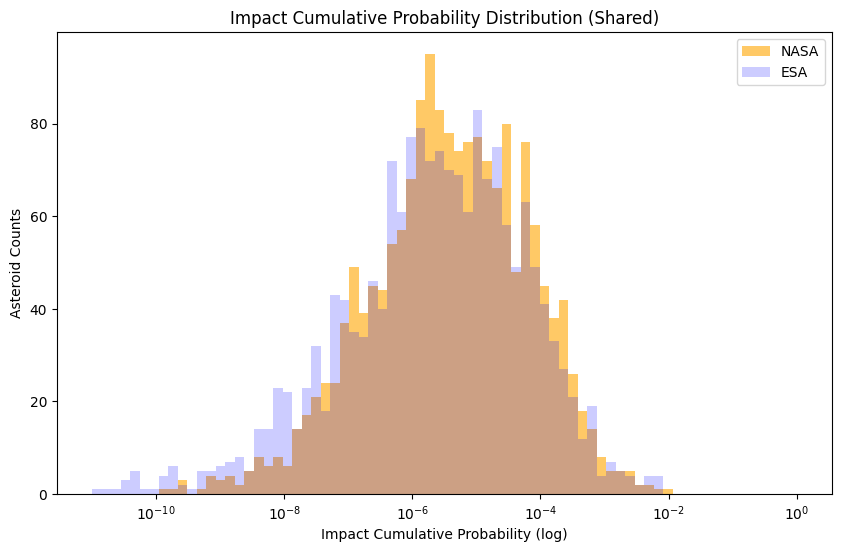

In [106]:
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.logspace(-11, 0, 75)

ax.hist(nasa_shared_ips, bins=bins, alpha=0.6, label='NASA', color='orange')
ax.hist(esa_shared_ips, bins=bins, alpha=0.2, label='ESA', color='blue')

ax.set_xscale('log')

ax.set_title("Impact Cumulative Probability Distribution (Shared)")
ax.set_xlabel("Impact Cumulative Probability (log)")
ax.set_ylabel("Asteroid Counts")

ax.legend();

plt.show()

In [107]:
def ip_agreement(nasa_shared_ips, esa_shared_ips, threshold_order=1.0):
    """
    Plots the agreement between NASA and ESA Impact Probabilities.
    Finds the threshold using a 95th percentile bin.
    """
    nasa = np.array(nasa_shared_ips, dtype=float)
    esa = np.array(esa_shared_ips, dtype=float)

    # Filter out 0 or NaN values
    valid = (nasa > 0) & (esa > 0) & np.isfinite(nasa) & np.isfinite(esa)
    nasa_clean = nasa[valid]
    esa_clean = esa[valid]

    # Mean
    x_geom_mean = np.sqrt(nasa_clean * esa_clean)

    # Log Difference
    y_log_diff = np.abs(np.log10(nasa_clean) - np.log10(esa_clean))

    # Color
    dot_colors = np.where(nasa_clean > esa_clean, 'gold', 'navy')

    # Binning for the 95th Percentile
    bins = np.logspace(np.log10(np.min(x_geom_mean)), np.log10(np.max(x_geom_mean)), 15)
    bin_centers = np.sqrt(bins[:-1] * bins[1:]) # Center of each bin for plotting
    
    perc_95 = np.zeros_like(bin_centers)
    
    for i in range(len(bins)-1):
        mask = (x_geom_mean >= bins[i]) & (x_geom_mean < bins[i+1])
        if np.sum(mask) > 0:
            perc_95[i] = np.percentile(y_log_diff[mask], 95)
        else:
            perc_95[i] = np.nan

    # Find the threshold
    divergence_ip = None
    
    for i in range(len(bin_centers) - 2, -1, -1):
        y2 = perc_95[i]      
        y1 = perc_95[i+1]    
        
        if np.isnan(y1) or np.isnan(y2):
            continue
            
        if y1 <= threshold_order and y2 > threshold_order:
            x1 = np.log10(bin_centers[i+1])
            x2 = np.log10(bin_centers[i])
            
            slope = (y2 - y1) / (x2 - x1)
            x_thresh = x1 + (threshold_order - y1) / slope
            
            divergence_ip = 10**x_thresh
            break

    # Plot
    plt.figure(figsize=(10, 7))
    ax = plt.gca()

    plt.scatter(x_geom_mean, y_log_diff, alpha=0.5, s=15, color=dot_colors, label='Asteroid IPs')

    plt.plot(bin_centers, perc_95, alpha=0.4, color='green', linewidth=2.5, marker='o', 
             label='95th Percentile')

    plt.axhline(threshold_order, color='red', linestyle='--', linewidth=1.5)
    
    if divergence_ip:
        plt.axvline(divergence_ip, alpha=0.5, color='purple', linestyle='-', linewidth=2)

    plt.xscale('log')
    ax.invert_xaxis() 

    plt.xlabel('Impact Probability (Mean)')
    plt.ylabel(r'Impact Probability Ratio ($\Delta y$ in Orders of Mag)')
    plt.title('NASA vs ESA Impact Probability Agreement')
    
    plt.grid(True, which="both", ls="--", alpha=0.3)
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='NASA IP > ESA IP', markerfacecolor='gold', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='ESA IP > NASA IP', markerfacecolor='navy', markersize=8),
        Line2D([0], [0], color='green', lw=2.5, marker='o', label='95th Percentile'),
        Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=f'Threshold ({threshold_order} Order of Mag)'),
        Line2D([0], [0], color='purple', lw=1.5, linestyle='-', label=f'Divergence Point ({divergence_ip:.1e})')
    ]
    plt.legend(handles=legend_elements, loc='upper left')
    
    plt.tight_layout()
    plt.show();

In [108]:
def align_and_plot(nasa_table, esa_table, nasa_ip_col='ip', esa_ip_col='ip_cum', threshold_order=1.0):
    """
    Aligns the NASA and ESA tables row by row, 
    """
    # Create clean names 
    nasa_table['clean_name'] = np.char.replace(np.array(nasa_table['des']).astype(str), ' ', '')
    esa_table['clean_name'] = np.char.replace(np.array(esa_table['object_name']).astype(str), ' ', '')
    nasa_sub = nasa_table['clean_name', nasa_ip_col]
    esa_sub = esa_table['clean_name', esa_ip_col]

    # Merge
    merged_data = join(nasa_sub, esa_sub, keys='clean_name', join_type='inner')
    
    # Extract
    aligned_nasa_ips = merged_data[nasa_ip_col]
    aligned_esa_ips = merged_data[esa_ip_col]

    # Plot
    ip_agreement(aligned_nasa_ips, aligned_esa_ips, threshold_order=threshold_order)


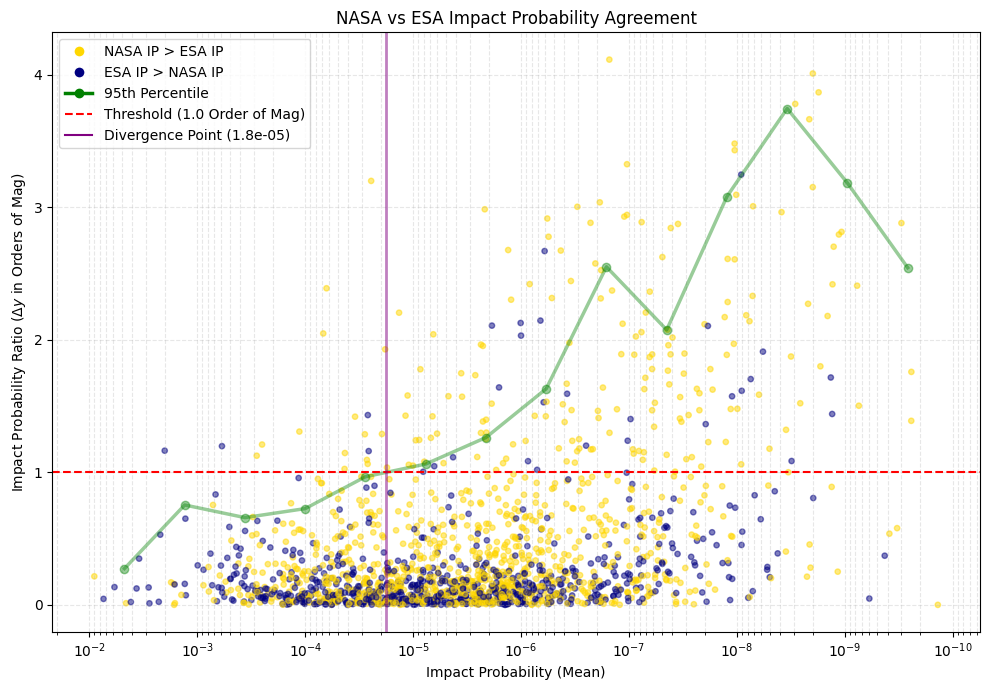

In [109]:
align_and_plot(nasa_shared, esa_shared, nasa_ip_col='ip', esa_ip_col='ip_cum', threshold_order=1.0)